In [87]:
import sys
sys.path.insert(0, "..")

import pandas as pd

df = pd.read_parquet("../data/raw/taxi/2024/yellow_tripdata_2024-01.parquet")

print(df.shape)
print(df.dtypes)
print(df.head())

(2964624, 19)
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
dtype: object
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         2  2024-01-01 00:57:55   2024-01-01 01:17:43              1.0   
1         1  2024-01-01 00:03:00   2024-01-01 00:09:36        

-9.250000000000002 38.35


<Axes: >

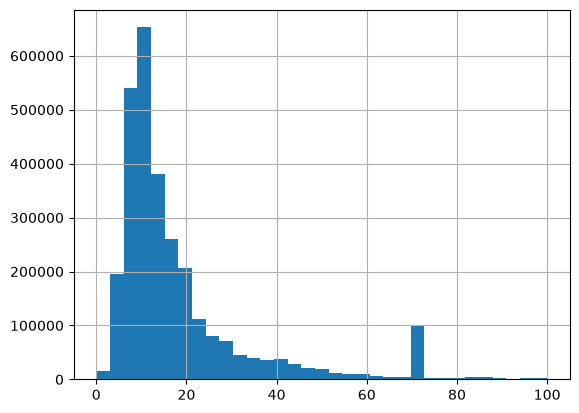

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

taxi = pd.read_parquet(Path("../data/raw/taxi/2024/yellow_tripdata_2024-01.parquet"))
Q1 = taxi["fare_amount"].quantile(0.25)
Q3 = taxi["fare_amount"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

taxi[taxi["fare_amount"].between(0, 100)]["fare_amount"].hist(bins=33)

In [113]:
import pandas as pd

taxi_raw = pd.read_parquet("../data/raw/taxi/2024/yellow_tripdata_2024-01.parquet")
taxi_clean = taxi_raw[(taxi_raw["trip_distance"] > 0) & (taxi_raw["fare_amount"] > 0)]
taxi_clean[["Airport_fee", "extra"]] = taxi_clean[["Airport_fee", "extra"]].fillna(0)

Q1 = taxi_clean["fare_amount"].quantile(0.25)
Q3 = taxi_clean["fare_amount"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)


-9.250000000000002 38.35


<Axes: >

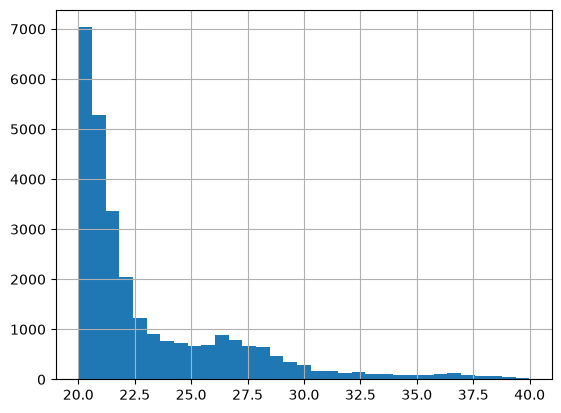

In [91]:
import pandas as pd
import matplotlib.pyplot as plt

taxi_raw = pd.read_parquet("../data/raw/taxi/2024/yellow_tripdata_2024-01.parquet")
taxi_clean = taxi_raw[(taxi_raw["trip_distance"] > 0) & (taxi_raw["fare_amount"] > 0)]
taxi_clean[["Airport_fee", "extra"]] = taxi_clean[["Airport_fee", "extra"]].fillna(0)
# taxi_clean[taxi_clean["fare_amount"].between(60, 80)]["fare_amount"].round().value_counts().sort_index()
# taxi_clean["fare_amount"].between(0, 150).mean()
taxi_clean[taxi_clean["trip_distance"].between(20, 40)]["trip_distance"].hist(bins=33)


In [92]:
print(df["tpep_pickup_datetime"].min())
print(df["tpep_pickup_datetime"].max())
print(df["PULocationID"].nunique())
print(df.isnull().sum())

2002-12-31 22:59:39
2024-02-01 00:01:15
260
VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          140162
trip_distance                 0
RatecodeID               140162
store_and_fwd_flag       140162
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     140162
Airport_fee              140162
dtype: int64


In [93]:
bad = df[("tpep_pickup_datetime" < "2024-01-01") | (df["tpep_pickup_datetime"] >= "2024-02-01")]
print(bad.shape)


(3, 19)


In [94]:
print(df['trip_distance'].describe())
print(df['fare_amount'].describe())

count    2.964624e+06
mean     3.652169e+00
std      2.254626e+02
min      0.000000e+00
25%      1.000000e+00
50%      1.680000e+00
75%      3.110000e+00
max      3.127223e+05
Name: trip_distance, dtype: float64
count    2.964624e+06
mean     1.817506e+01
std      1.894955e+01
min     -8.990000e+02
25%      8.600000e+00
50%      1.280000e+01
75%      2.050000e+01
max      5.000000e+03
Name: fare_amount, dtype: float64


In [95]:
print(df[df['trip_distance'] <= 0].shape[0] / df.shape[0])
print(df[df['fare_amount'] <= 0].shape[0] / df.shape[0])
df = df[(df['trip_distance'] > 0) & (df['fare_amount'] > 0)]
print(df.shape[0])

0.020363796555650904
0.012932837351380816
2869714


In [96]:
df['pickup_hour'] = df["tpep_pickup_datetime"].dt.hour
df["pickup_dow"] = df['tpep_pickup_datetime'].dt.day_of_week
print(df[["tpep_pickup_datetime", "pickup_hour", "pickup_dow"]].tail(15))

        tpep_pickup_datetime  pickup_hour  pickup_dow
2964609  2024-01-31 23:40:27           23           2
2964610  2024-01-31 23:49:00           23           2
2964611  2024-01-31 23:01:28           23           2
2964612  2024-01-31 23:52:57           23           2
2964613  2024-01-31 23:16:55           23           2
2964614  2024-01-31 23:23:02           23           2
2964615  2024-01-31 23:54:30           23           2
2964616  2024-01-31 23:40:02           23           2
2964617  2024-01-31 23:27:00           23           2
2964618  2024-01-31 23:18:48           23           2
2964619  2024-01-31 23:45:59           23           2
2964620  2024-01-31 23:13:07           23           2
2964621  2024-01-31 23:19:00           23           2
2964622  2024-01-31 23:07:23           23           2
2964623  2024-01-31 23:58:25           23           2


In [97]:
demand = df.groupby(["PULocationID", "pickup_hour", "pickup_dow"]).size().reset_index(name="trip_count")
print(demand.shape)

(25322, 4)


In [98]:
print(round((demand["trip_count"] >= 10).mean() * 100, 2))


40.3


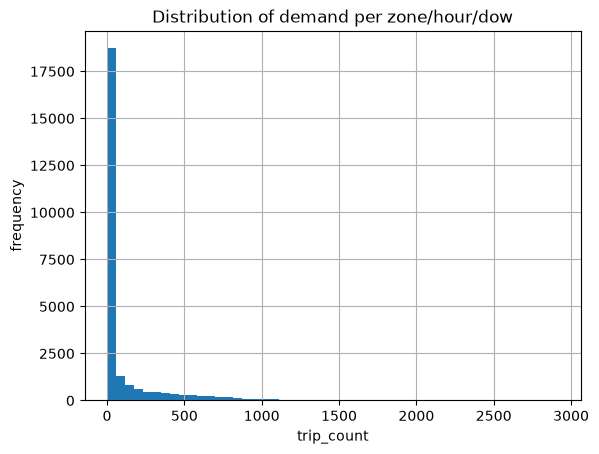

In [99]:
import matplotlib.pyplot as plt

demand["trip_count"].hist(bins=50)
plt.xlabel("trip_count")
plt.ylabel("frequency")
plt.title("Distribution of demand per zone/hour/dow")
plt.show()


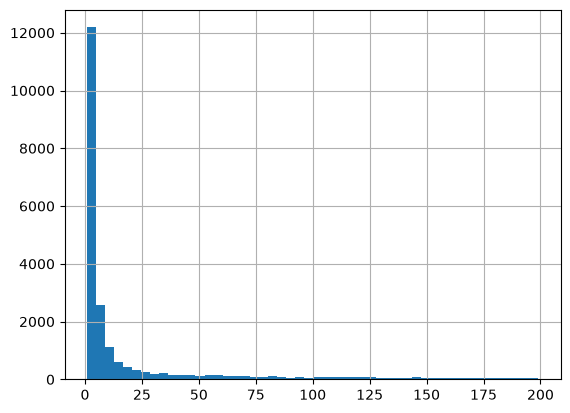

In [100]:
demand[demand["trip_count"] < 200]["trip_count"].hist(bins=50)
plt.show()

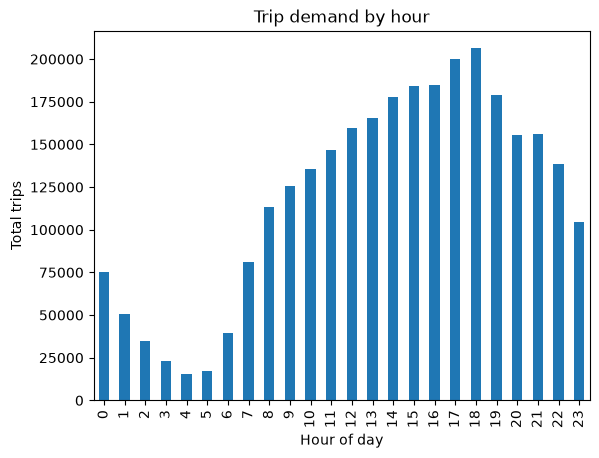

In [101]:
hourly = df.groupby("pickup_hour").size()
hourly.plot(kind="bar")
plt.xlabel("Hour of day")
plt.ylabel("Total trips")
plt.title("Trip demand by hour")
plt.show()


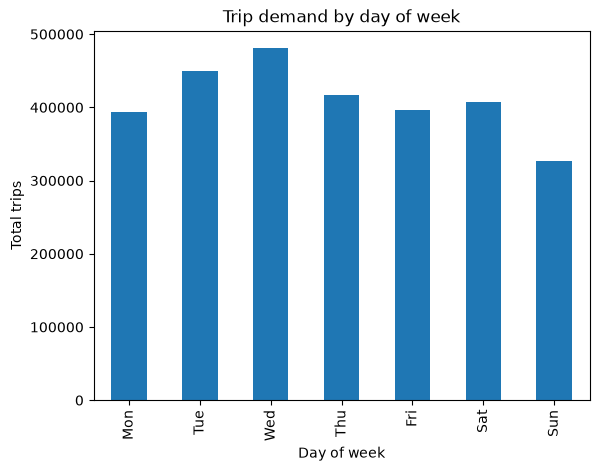

In [102]:
daily = df.groupby("pickup_dow").size()
daily.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
daily.plot(kind="bar")
plt.xlabel("Day of week")
plt.ylabel("Total trips")
plt.title("Trip demand by day of week")
plt.show()


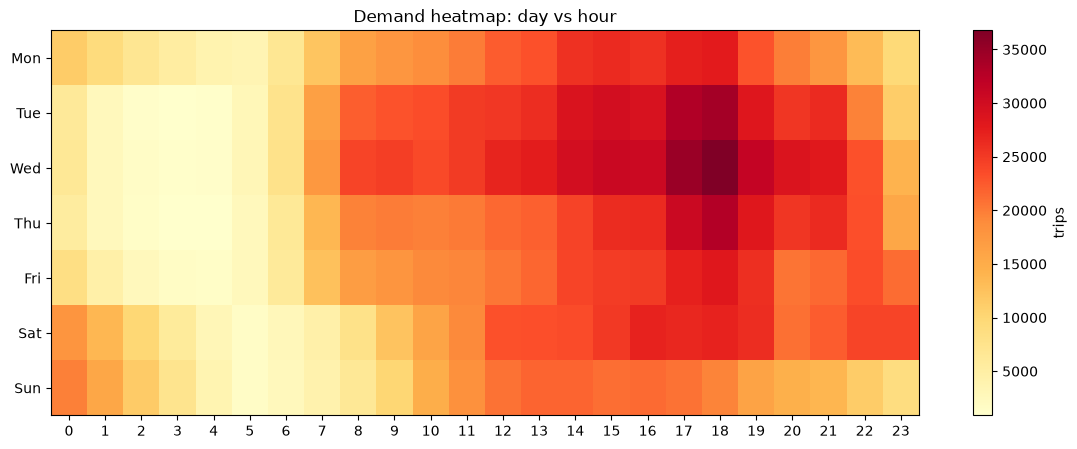

In [103]:
import numpy as np

pivot = df.groupby(["pickup_dow", "pickup_hour"]).size().unstack()
pivot.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(14, 5))
plt.imshow(pivot, aspect="auto", cmap="YlOrRd")
plt.colorbar(label="trips")
plt.xticks(range(24), range(24))
plt.yticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.title("Demand heatmap: day vs hour")
plt.show()


In [104]:
top_zones = df.groupby("PULocationID").size().sort_values(ascending=False).head(20)
print(top_zones)


PULocationID
161    140142
237    140121
132    138450
236    133962
162    104345
230    102958
186    102153
142    101794
138     87697
239     86468
163     83678
170     80955
68      75546
234     74374
48      74074
141     72163
249     64281
140     64197
79      63601
164     63076
dtype: int64


In [105]:
import pandas as pd

df = pd.read_parquet(r"c:\Users\Таня\Desktop\Folder\Programming\uber\data\raw\weather\2024\open-meteo-2024.parquet")

df[["temperature_2m", "precipitation", "snowfall"]].isna().sum()


temperature_2m    0
precipitation     0
snowfall          0
dtype: int64

In [106]:
import pandas as pd

# demand = pd.read_parquet("../data/processed/demand.parquet")
taxi = pd.read_parquet("../data/raw/taxi/2024/yellow_tripdata_2024-01.parquet")
weather = pd.read_parquet("../data/raw/weather/2024/open-meteo-2024.parquet")

print(taxi["tpep_pickup_datetime"].dtype)
print(weather["time"].dtype)


datetime64[us]
str


In [107]:
demand = pd.read_parquet("../data/processed/demand.parquet")
weather = pd.read_parquet("../data/raw/weather/2024/open-meteo-2024.parquet")

print(demand["pickup_hour_ts"].head())
print(weather["time"].head())


0   2024-01-01 06:00:00
1   2024-01-01 14:00:00
2   2024-01-01 16:00:00
3   2024-01-01 17:00:00
4   2024-01-02 18:00:00
Name: pickup_hour_ts, dtype: datetime64[us]
0    2024-01-01T00:00
1    2024-01-01T01:00
2    2024-01-01T02:00
3    2024-01-01T03:00
4    2024-01-01T04:00
Name: time, dtype: str


In [108]:
import datetime
from pathlib import Path
ts = Path("../data/processed/demand.parquet").stat().st_mtime
print(datetime.datetime.fromtimestamp(ts))


2026-09-25 16:25:51.182869


In [109]:
import pandas as pd

demand = pd.read_parquet("../data/processed/demand.parquet")
weather = pd.read_parquet("../data/raw/weather/2024/open-meteo-2024.parquet")

weather = weather.rename(columns={"time": "pickup_hour_ts"})
weather["pickup_hour_ts"] = pd.to_datetime(weather["pickup_hour_ts"]).dt.tz_localize(None)

merged = demand.merge(weather[["pickup_hour_ts", "temperature_2m"]], on="pickup_hour_ts", how="left")
print(demand.columns.tolist())
print(demand.index.name)
print(pd.Timestamp(1704088800000, unit="ms"))


['PULocationID', 'pickup_hour_ts', 'trip_count', 'pickup_hour', 'pickup_dow', 'pickup_week', 'pickup_is_weekend', 'temperature_2m', 'precipitation', 'snowfall']
None
2024-01-01 06:00:00
